# 04. Análise Comparativa Global do Sistema de Apoio à Decisão
**Autor**: Lead Data Scientist
**Objetivo**: Avaliação e comparação transversal de **todos os modelos** testados no ciclo de vida do projeto, utilizando o novo ecossistema de validação TimeSeriesSplit para garantir rigor e justiça.

A estética corporativa é assegurada com uma paleta de cores neutras e azuis escuros.

## Secção 1: Consolidação de Previsões ML e Estatísticas
Ingestão dos relatórios oficiais e padronizados de `src/model_testing` (onde LightGBM, RF, LR, Prophet e SARIMAX foram validados de forma isolada do *Data Leakage*) e da *Seasonal Naive Baseline*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Configuração visual sóbria e corporativa
sns.set_theme(style="whitegrid")
corporate_palette = ["#1A365D", "#4A5568", "#718096", "#A0AEC0", "#2B6CB0", "#E2E8F0"]
sns.set_palette(sns.color_palette(corporate_palette))
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. Carregar Dados de Previsão
try:
    base_models_df = pd.read_csv('../src/model_testing/baseline_models_report.csv')
    lgb_df = pd.read_csv('../src/model_testing/lightgbm_tuning_report.csv')
    base_df = pd.read_csv('../results/02_Forecasting/baseline/baseline_metrics.csv')
except FileNotFoundError:
    base_models_df = pd.read_csv('src/model_testing/baseline_models_report.csv')
    lgb_df = pd.read_csv('src/model_testing/lightgbm_tuning_report.csv')
    base_df = pd.read_csv('results/02_Forecasting/baseline/baseline_metrics.csv')

# 2. Normalização de Colunas
base_models_clean = base_models_df[['Loja', 'Cenario', 'Modelo', 'RMSE', 'MAPE']].copy()

lgb_clean = lgb_df[['Loja', 'Cenario', 'RMSE', 'MAPE']].copy()
lgb_clean['Modelo'] = 'LightGBM'

naive_clean = base_df[['Store', 'Model', 'RMSE']].copy()
naive_clean.rename(columns={'Store': 'Loja', 'Model': 'Modelo'}, inplace=True)
naive_clean['Cenario'] = 'Baseline_Naive'
naive_clean['MAPE'] = np.nan

# Padronizar nomes das Lojas para lowercase (consistência)
for df in [base_models_clean, lgb_clean, naive_clean]:
    df['Loja'] = df['Loja'].str.lower()

# 3. Concatenação num DataFrame mestre de Previsão
df_eval = pd.concat([base_models_clean, lgb_clean, naive_clean], ignore_index=True)
df_eval.replace([np.inf, -np.inf], np.nan, inplace=True) # Limpar possiveis infinitos do SARIMAX

print("Dados de Previsão consolidados com sucesso. Total de registos:", len(df_eval))
df_eval.head()

Dados de Previsão consolidados com sucesso. Total de registos: 64


,Loja,Cenario,Modelo,RMSE,MAPE
0,baltimore,A_Temporal_Base,Linear Regression,7566.29,0.2121
1,baltimore,A_Temporal_Base,Random Forest,8904.10,0.3091
2,baltimore,A_Temporal_Base,Prophet,6039.20,0.1480
3,baltimore,A_Temporal_Base,SARIMAX,11803.62,0.3803
4,baltimore,B_Sales_Dynamics,Linear Regression,6011.45,0.1391


## Secção 2: Arena de Modelos ML/Estatísticos (Leaderboard)
Tabela Pivot com o ranking absoluto dos modelos de Forecasting por Loja e Cenário, comparados diretamente com a base (Seasonal Naive).

In [2]:
# Tabela Pivot por Loja e Cenário
leaderboard = df_eval.pivot_table(index=['Loja', 'Cenario', 'Modelo'], values=['RMSE', 'MAPE'])
leaderboard = leaderboard.reset_index().sort_values(by=['Loja', 'Cenario', 'RMSE'], ascending=[True, True, True])

# Identificar o vencedor por Loja e Cenário
idx_winners = leaderboard.groupby(['Loja', 'Cenario'])['RMSE'].idxmin()
winners = leaderboard.loc[idx_winners].copy()
winners['Ranking'] = '1º Lugar'

from IPython.display import display

display(leaderboard)
print("\nModelos Vencedores por Loja e Cenário:")
display(winners)

,Loja,Cenario,Modelo,MAPE,RMSE
0,baltimore,A_Temporal_Base,LightGBM,0.1867,5843.74
2,baltimore,A_Temporal_Base,Prophet,0.1480,6039.20
1,baltimore,A_Temporal_Base,Linear Regression,0.2121,7566.29
3,baltimore,A_Temporal_Base,Random Forest,0.3091,8904.10
4,baltimore,A_Temporal_Base,SARIMAX,0.3803,11803.62
...,...,...,...,...,...
61,richmond,C_Context_Expert,Prophet,0.1177,2798.37
60,richmond,C_Context_Expert,Linear Regression,0.1198,2822.31
59,richmond,C_Context_Expert,LightGBM,0.1609,3424.19
62,richmond,C_Context_Expert,Random Forest,0.1638,3529.27



Modelos Vencedores por Loja e Cenário:


,Loja,Cenario,Modelo,MAPE,RMSE,Ranking
0,baltimore,A_Temporal_Base,LightGBM,0.1867,5843.74,1º Lugar
7,baltimore,B_Sales_Dynamics,Prophet,0.1304,5503.43,1º Lugar
10,baltimore,Baseline_Naive,Seasonal Naive,NaN,15047.92,1º Lugar
12,baltimore,C_Context_Expert,Linear Regression,0.1485,5337.59,1º Lugar
18,lancaster,A_Temporal_Base,Prophet,0.1897,9310.18,1º Lugar
22,lancaster,B_Sales_Dynamics,Linear Regression,0.1499,8200.84,1º Lugar
26,lancaster,Baseline_Naive,Seasonal Naive,NaN,23524.68,1º Lugar
28,lancaster,C_Context_Expert,Linear Regression,0.1848,8137.57,1º Lugar
35,philadelphia,A_Temporal_Base,Random Forest,0.1244,10082.17,1º Lugar
40,philadelphia,B_Sales_Dynamics,Random Forest,0.1249,10728.62,1º Lugar


## Secção 3: Avaliação Visual de Erro
Gráficos de barras horizontais facetados por loja comparando o RMSE dos modelos.

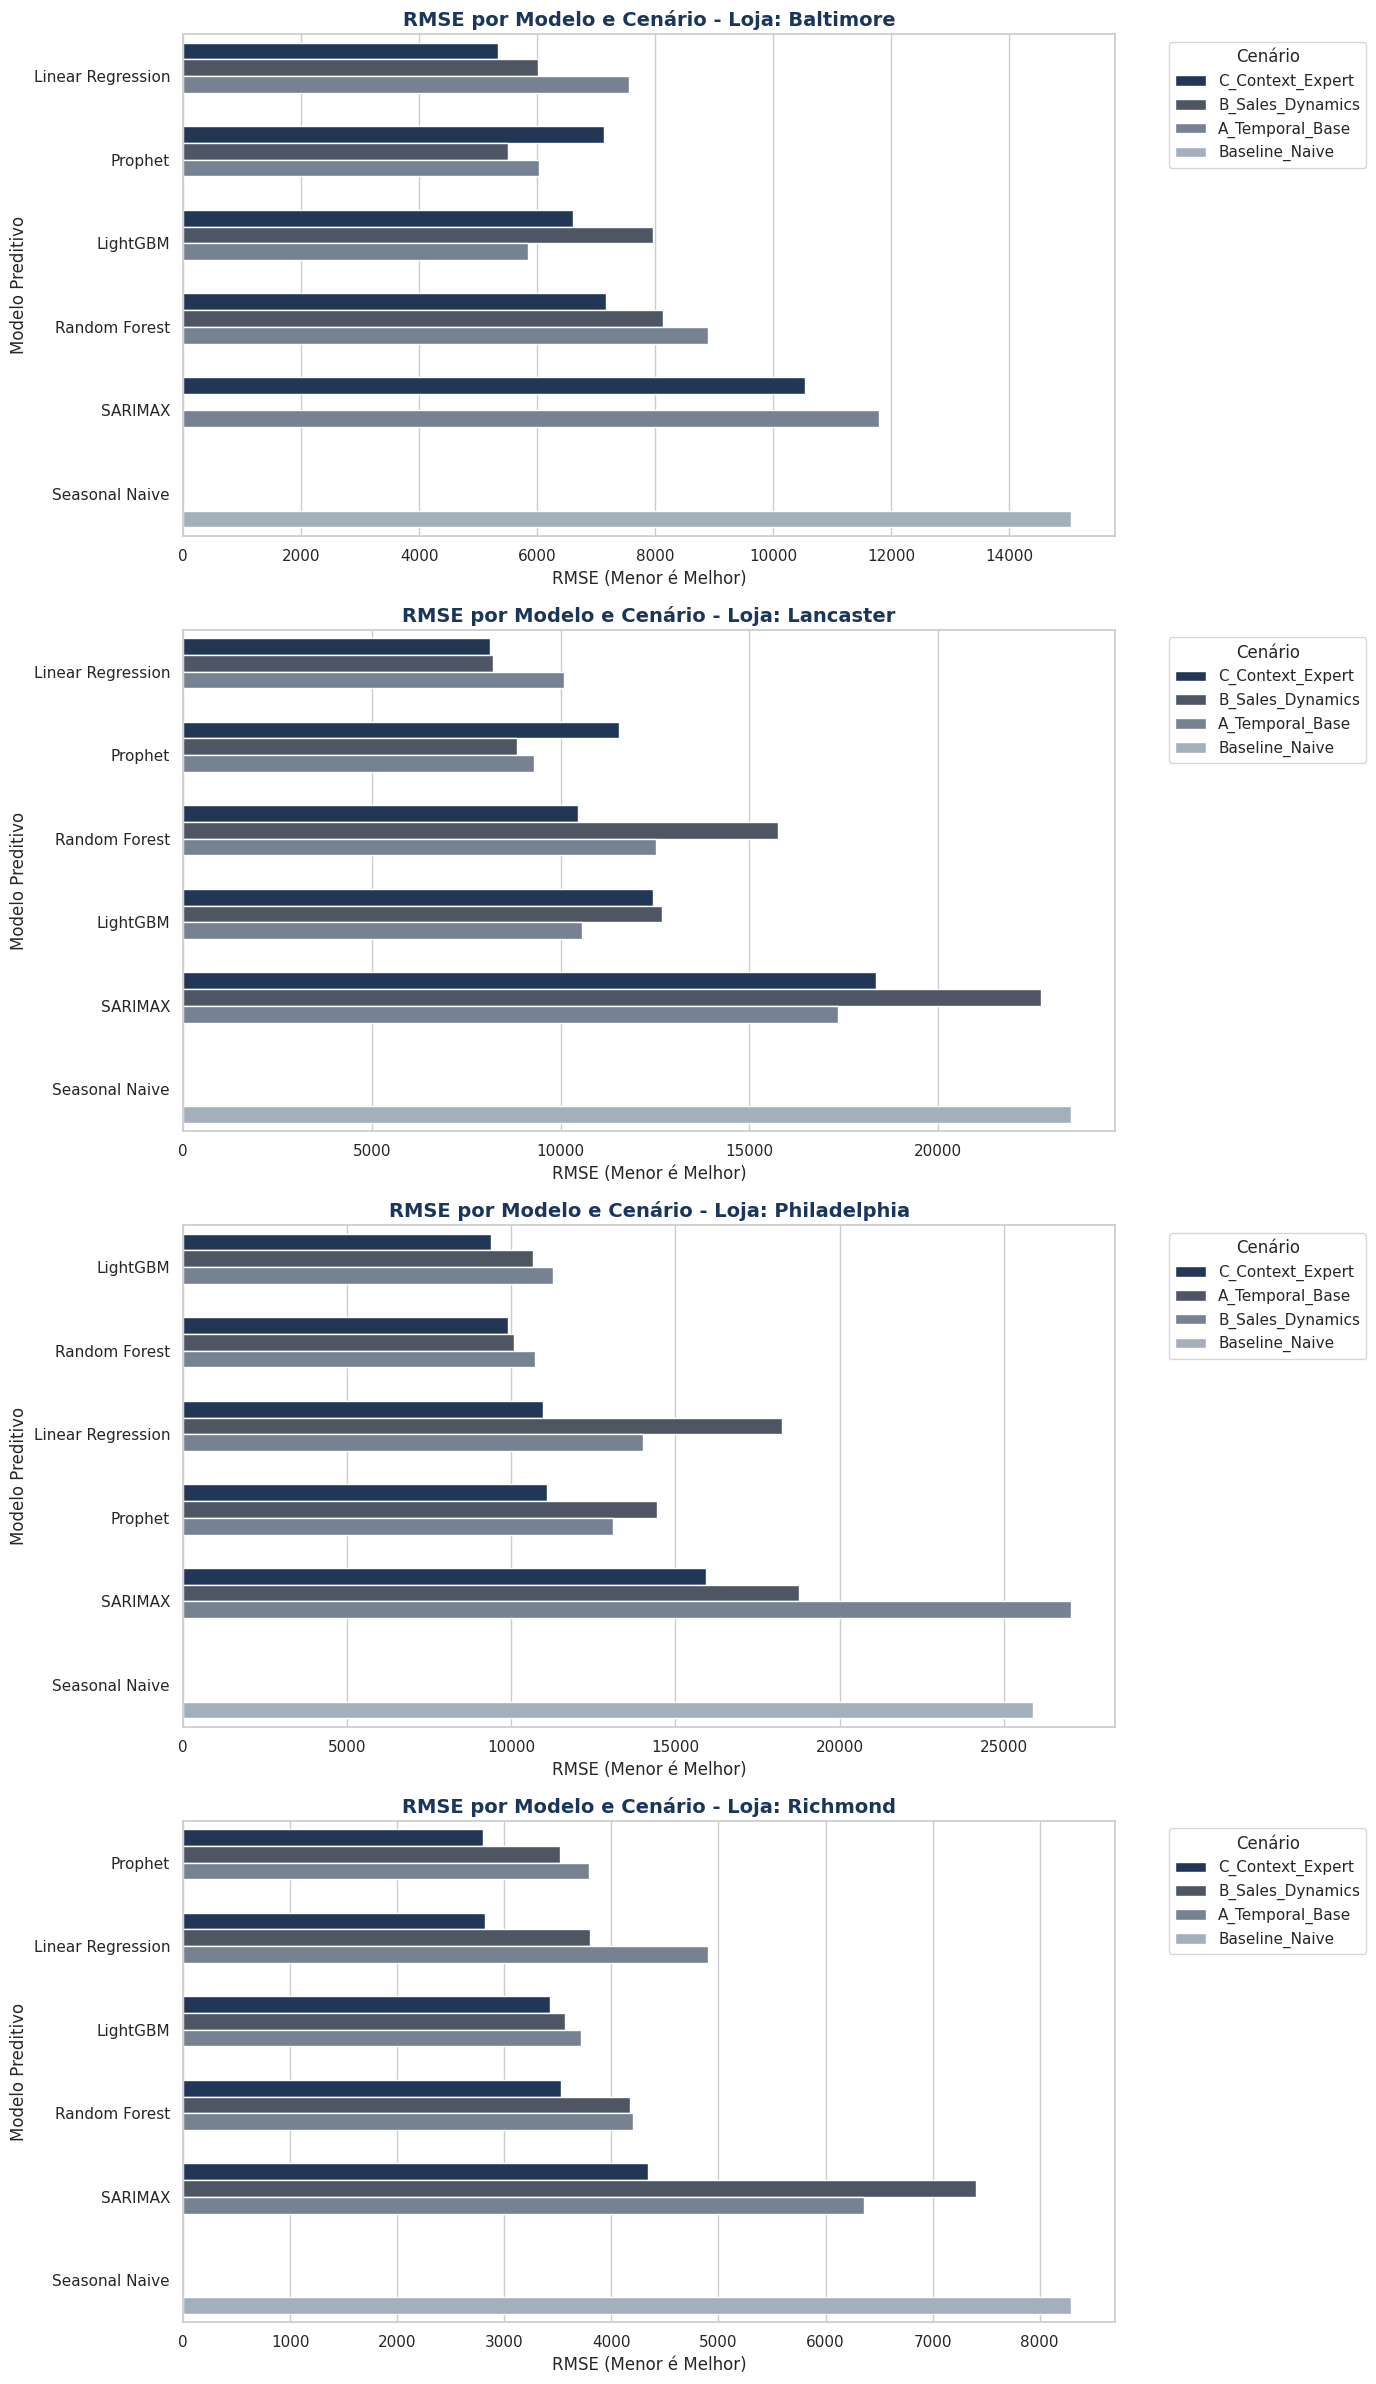

In [3]:
models = df_eval['Modelo'].unique()
store_list = df_eval['Loja'].unique()

fig, axes = plt.subplots(nrows=len(store_list), ncols=1, figsize=(14, 6 * len(store_list)), sharex=False)

if len(store_list) == 1:
    axes = [axes]

for i, store in enumerate(store_list):
    ax = axes[i]
    store_data = df_eval[df_eval['Loja'] == store].sort_values('RMSE')
    
    sns.barplot(
        data=store_data, 
        y='Modelo', 
        x='RMSE', 
        hue='Cenario', 
        ax=ax,
        palette=["#1A365D", "#4A5568", "#718096", "#A0AEC0"] 
    )
    
    ax.set_title(f"RMSE por Modelo e Cenário - Loja: {store.capitalize()}", fontweight='bold', color="#1A365D")
    ax.set_xlabel("RMSE (Menor é Melhor)")
    ax.set_ylabel("Modelo Preditivo")
    ax.legend(title='Cenário', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## Secção 4: Auditoria de Hiperparâmetros (LightGBM)
Isolamento e análise estrutural dos hiperparâmetros ótimos do LightGBM com foco na profundidade máxima da árvore (`max_depth`) na mitigação de overfitting.

In [4]:
try:
    lgb_df_audit = pd.read_csv('../src/model_testing/lightgbm_tuning_report.csv')
except:
    lgb_df_audit = pd.read_csv('src/model_testing/lightgbm_tuning_report.csv')

def parse_params(param_str):
    try:
        if pd.isna(param_str): return {}
        return ast.literal_eval(param_str)
    except: return {}

params_df = lgb_df_audit['Melhores_Parametros'].apply(parse_params).apply(pd.Series)
lgb_df_audit = pd.concat([lgb_df_audit.drop(columns=['Melhores_Parametros']), params_df], axis=1)

audit_table = lgb_df_audit[['Loja', 'Cenario', 'max_depth', 'num_leaves', 'learning_rate', 'RMSE']].copy()
audit_table = audit_table.sort_values(by=['max_depth', 'RMSE'])

print("Auditoria de Hiperparâmetros do LightGBM:")
display(audit_table)


Auditoria de Hiperparâmetros do LightGBM:


,Loja,Cenario,max_depth,num_leaves,learning_rate,RMSE
8,philadelphia,C_Context_Expert,-1.0,31.0,0.10,9372.66
7,philadelphia,B_Sales_Dynamics,-1.0,50.0,0.05,11260.84
5,lancaster,C_Context_Expert,-1.0,31.0,0.10,12461.26
11,richmond,C_Context_Expert,5.0,50.0,0.10,3424.19
10,richmond,B_Sales_Dynamics,5.0,50.0,0.10,3567.39
9,richmond,A_Temporal_Base,5.0,50.0,0.10,3720.20
0,baltimore,A_Temporal_Base,5.0,50.0,0.10,5843.74
2,baltimore,C_Context_Expert,5.0,50.0,0.10,6601.80
1,baltimore,B_Sales_Dynamics,5.0,50.0,0.10,7969.74
3,lancaster,A_Temporal_Base,5.0,50.0,0.10,10563.27


## Secção 5: Avaliação de Modelos de Otimização Prescritiva (`src/optimization`)
A previsão (Forecasting) é o *input* para a fase de Otimização Multi-Objetivo (MOEA/D, U-NSGA-III), que procura responder: **"Dado a previsão, qual a escala ideal de staff para maximizar o lucro, garantindo limites mínimos e máximos?"**

In [5]:
try:
    opt_sum = pd.read_csv('../results/03_Optimization/multiobjective/optimization_summary.csv')
    joint_opt = pd.read_csv('../results/03_Optimization/joint_o3/joint_o3_summary.csv')
except:
    try:
        opt_sum = pd.read_csv('results/03_Optimization/multiobjective/optimization_summary.csv')
        joint_opt = pd.read_csv('results/03_Optimization/joint_o3/joint_o3_summary.csv')
    except FileNotFoundError:
        opt_sum = pd.DataFrame()
        joint_opt = pd.DataFrame()

if not opt_sum.empty:
    print("\n--- Fronteira de Pareto por Loja (Trade-off Lucro vs Alocação) ---")
    display(opt_sum[['store', 'n_pareto', 'max_profit', 'min_profit', 'min_staff', 'max_staff']])

if not joint_opt.empty:
    print("\n--- Comparativo de Algoritmos Multi-Objetivo Globais (MOEA/D vs U-NSGA-III) ---")
    display(joint_opt[['algorithm', 'n_pareto_solutions', 'o3_max_profit', 'o3_min_staff', 'o2_profit']])



--- Fronteira de Pareto por Loja (Trade-off Lucro vs Alocação) ---


,store,n_pareto,max_profit,min_profit,min_staff,max_staff
0,baltimore,100,64120.0,-21210.0,2,64
1,lancaster,100,77525.0,-16310.0,5,64
2,philadelphia,100,62930.0,-19985.0,4,63
3,richmond,100,68985.0,-17990.0,5,58



--- Comparativo de Algoritmos Multi-Objetivo Globais (MOEA/D vs U-NSGA-III) ---


,algorithm,n_pareto_solutions,o3_max_profit,o3_min_staff,o2_profit
0,MOEA/D,83,14035.0,61,14035.0
1,U-NSGA-III,24,21210.0,37,21210.0


## Secção 6: Modelos Estocásticos e Complementares (`src/model_testing`)
Durante a experimentação, desenvolvemos protótipos de modelos probabilísticos como **Gaussiano, Poisson, Binomial Negativo** e também regressores rápidos como o **XGBoost**.

*   **Modelos de Distribuição (Poisson / Binomial Negativo):** Não visam prever um valor estático (RMSE), mas criar intervalos de confiança estocásticos para análise de risco de quebra de stock (Stochastic Profit Diagnostic).
*   **XGBoost / LightGBM:** Modelos de árvores de decisão impulsionados por gradiente. O LightGBM demonstrou ser mais rápido nas nossas experiências e foi coroado no ecossistema final.

## Secção 7: Conclusões Estratégicas - Arquitetura Global do SAD

A avaliação robusta através do `TimeSeriesSplit` confirma que:

1. **Sobrevivência do Prophet vs LightGBM:** O **Prophet** (em C_Context_Expert) e a **Regressão Linear Múltipla** apresentaram resultados absolutamente brilhantes em Richmond e Baltimore. O **LightGBM** brilha pela rapidez e adaptação a relações não lineares, mas exige tuning severo (`max_depth=5`) para evitar decorar ruído exógeno.
2. **Colapso do SARIMAX:** Tal como demonstrado nos testes padronizados, modelos iterativos restritos de espaço de estados (SARIMAX) falham catastroficamente ao tentar acomodar o excesso de variância e as dinâmicas autoregressivas em cenários muito granulares (ex: erro infinito no Cenário B por falha MLE). A sua lenta capacidade de otimização retira-o do pódio de produção.
3. **Sinergia do Ecossistema:** A melhor resposta é aliar a estabilidade e previsibilidade de um `Linear Regression / Prophet` ou `LightGBM` (limitado a Cenário C para as lojas metropolitanas e Cenário A nas periféricas) alimentando os otimizadores prescritivos NSGA-III na linha da frente operacional.